# House Prices - Advanced Regression Techniques

## Final Exam Project (Retake) – Machine Learning

**Author:** Todor Yankov  
**Course:** Machine Learning  
**Project Type:** Technical Report with Experimental Evaluation  
**Date:** July 2026

---

## Executive Summary

This project investigates the problem of predicting residential house sale prices using the **House Prices – Advanced Regression Techniques** dataset from Kaggle.

The objective is to develop an accurate and interpretable machine learning pipeline capable of estimating house prices based on structural, geographical, and quality-related characteristics of residential properties located in Ames, Iowa.

Rather than focusing solely on achieving a high Kaggle score, this project aims to demonstrate a complete machine learning workflow, including data exploration, mathematical foundations, feature engineering, model development, hyperparameter optimization, ensemble learning, model explainability, and experimental evaluation.

The proposed solution combines several complementary regression models using a Ridge Regression stacking meta-learner. The final model is further combined with an H2O AutoML ensemble, producing a **public Kaggle RMSLE score of 0.11921**, placing the solution among the top-performing submissions.

Throughout this notebook, every modelling decision is justified, experimental improvements are analysed, and the strengths and limitations of the proposed approach are discussed. 

# 1. Introduction

House price prediction is one of the most widely studied regression problems in machine learning. Accurate property valuation is important for buyers, sellers, real estate agencies, banks, insurance companies, and investors, where reliable price estimates support financial and business decisions.

Unlike simple linear prediction tasks, house prices depend on many interacting factors, including property size, construction quality, neighborhood, age of the building, garage capacity, basement characteristics, and many other structural attributes. These relationships are often nonlinear, making the problem particularly suitable for modern machine learning techniques.

This project is based on the **House Prices – Advanced Regression Techniques** Kaggle competition. The dataset contains **79 explanatory variables** describing residential properties in Ames, Iowa. The objective is to predict the final sale price (`SalePrice`) of each house as accurately as possible.

From a machine learning perspective, this is a **supervised regression problem**, where historical observations with known sale prices are used to train predictive models capable of estimating prices for previously unseen houses.

The project follows a complete machine learning workflow, starting with exploratory data analysis and data preprocessing, followed by feature engineering, model development, hyperparameter optimization, ensemble learning, explainable artificial intelligence (XAI), and experimental evaluation. 

# 2. Problem Formulation

The task is to predict the sale price of a house based on a set of explanatory variables describing its physical, qualitative, and location-related characteristics.

Let each house be represented by a feature vector

$$
\mathbf{x}_i =
(x_{i1}, x_{i2}, \ldots, x_{ip})
$$

where:

- $\mathbf{x}_i$ is the feature vector for the $i$-th house,
- $p$ is the number of explanatory variables,
- $y_i$ is the true sale price of the $i$-th house.

The goal is to learn a function

$$
f(\mathbf{x}_i) \approx y_i
$$

that can generalize well to unseen houses from the test dataset.

Since house prices are positive and strongly right-skewed, the target variable is transformed using

$$
z_i = \log(y_i + 1)
$$

The model is trained to predict $z_i$ instead of directly predicting $y_i$. After prediction, the inverse transformation is applied:

$$
\hat{y}_i = \exp(\hat{z}_i) - 1
$$

This transformation is useful because it reduces the influence of very expensive houses and makes the prediction task more consistent with the RMSLE evaluation metric.

Therefore, the machine learning objective is to minimize the prediction error in logarithmic price space while maintaining good generalization on unseen data. 

## 3. Mathematical Background

### RMSLE (Root Mean Squared Log Error)

The competition uses **RMSLE** as the evaluation metric. It is defined as:

\[
\text{RMSLE} = \sqrt{ \frac{1}{n} \sum_{i=1}^{n} \left( \log(y_i + 1) - \log(\hat{y}_i + 1) \right)^2 }
\]

where:
- \( y_i \) is the actual sale price,
- \( \hat{y}_i \) is the predicted sale price,
- \( \log \) is the natural logarithm (base \( e \)).

**Why RMSLE?**
1.  **Handling Skewness**: It penalizes underestimation more than overestimation, which is suitable for skewed price distributions.
2.  **Relative Error**: It approximates the relative error, meaning it measures the percentage error rather than absolute error. This makes it robust to outliers in high price ranges.
3.  **Log Transformation**: By using log(price+1), we make the target distribution more normal (Gaussian), which is an assumption for many linear and tree-based models. 

## 3.1 Root Mean Squared Logarithmic Error (RMSLE)

The Kaggle competition evaluates all submissions using the **Root Mean Squared Logarithmic Error (RMSLE)**. Unlike the traditional Root Mean Squared Error (RMSE), RMSLE compares predictions on a logarithmic scale, making it particularly suitable for datasets where the target variable is highly skewed.

The metric is defined as

$$
\mathrm{RMSLE}
=
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
\left(
\log(y_i+1)-\log(\hat{y}_i+1)
\right)^2
}
$$

where

- $n$ is the number of observations,
- $y_i$ is the actual sale price,
- $\hat{y}_i$ is the predicted sale price.

### Why RMSLE?

RMSLE was selected because it is well suited for house price prediction.

Its main advantages are:

- It reduces the influence of extremely expensive houses through logarithmic transformation.
- It evaluates prediction errors on a relative rather than an absolute scale.
- It is less sensitive to outliers than RMSE.
- It is the official evaluation metric of the Kaggle competition, making it the most appropriate optimization objective for this project.

For these reasons, the target variable is transformed using `log1p(SalePrice)` before training, while the inverse transformation `expm1()` is applied to obtain predictions in the original price scale. 

In [1]:
# 4. Environment Setup
%pip install lightgbm 

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Load Libraries and Data

In [2]:
# ==========================================
# Standard libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Machine Learning
# ==========================================

from sklearn.model_selection import (
    KFold,
    cross_val_score,
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

from sklearn.linear_model import Ridge

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# ==========================================
# Gradient Boosting Libraries
# ==========================================

import xgboost as xgb
import lightgbm as lgb

# ==========================================
# Explainability
# ==========================================

import shap

# ==========================================
# Display options
# ==========================================

pd.set_option("display.max_columns", None)
plt.style.use("ggplot")

print("Libraries loaded successfully.") 

Libraries loaded successfully.


# 5. Load Dataset

In this section, the training and test datasets are loaded from the local `data/` directory.

The training dataset contains the target variable `SalePrice`, while the test dataset contains the same explanatory variables without the target. Before any modelling step, it is important to verify that both datasets are loaded correctly and that their dimensions match the expected Kaggle structure. 

In [3]:
# ==========================================
# Load datasets
# ==========================================

train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

print(f"Train shape: {train.shape}")
print(f"Test shape : {test.shape}") 

Train shape: (1460, 81)
Test shape : (1459, 80)


### Interpretation

The training dataset contains **1,460 observations** and **81 variables**, including the target variable `SalePrice`. The test dataset contains **1,459 observations** and **80 explanatory variables**, matching the structure of the official Kaggle competition.

The difference of one column confirms that the target variable is available only in the training data, while the objective is to predict it for the unseen test instances.

This verification ensures that the datasets have been loaded correctly and are ready for exploratory data analysis. 

# 6. Exploratory Data Analysis (EDA)

Before developing any machine learning model, it is essential to understand the structure and quality of the dataset.

Exploratory Data Analysis (EDA) provides an overview of the available features, their data types, descriptive statistics, and potential data quality issues such as missing values or unusual distributions.

The objective of this section is to answer the following questions:

- What information does the dataset contain?
- Which variables are numerical and which are categorical?
- Are there missing values?
- Are there obvious anomalies or outliers?
- What preprocessing steps will be required before model training?

The insights obtained during EDA will guide the subsequent feature engineering and modelling decisions. 

## 6.1 Initial Dataset Overview

In [4]:
# Display the first five observations
train.head() 

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Interpretation

The first five observations provide an initial overview of the dataset structure. Each row represents a residential property, while each column corresponds to a specific feature describing the property.

The training dataset contains **81 variables**, including the target variable `SalePrice`. The remaining variables describe different aspects of each property, such as:

- physical characteristics (e.g., living area, basement size, garage capacity),
- construction quality and overall condition,
- location and neighborhood,
- building age and renovation history,
- exterior and interior materials.

A preliminary inspection also reveals the presence of missing values (`NaN`) in several columns, such as `Alley`, `FireplaceQu`, `PoolQC`, and `Fence`. At this stage, these missing values are not treated as errors, since in many cases they indicate the absence of a particular property feature rather than missing information.

This initial inspection confirms that the dataset contains a rich combination of numerical and categorical variables, making it suitable for applying advanced feature engineering and ensemble machine learning techniques. 

In [5]:
# Display dataset structure
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

### Interpretation

The `info()` summary provides an overview of the dataset structure, data types, and completeness.

Several important observations can be made:

- The training dataset contains **1,460 observations** and **81 variables**, including the target variable `SalePrice`.
- The features consist of **35 integer variables**, **3 floating-point variables**, and **43 categorical variables**.
- The dataset therefore contains a balanced mixture of numerical and categorical information, requiring different preprocessing techniques before model training.
- Several variables contain missing values. For example, `LotFrontage`, `Alley`, `FireplaceQu`, `PoolQC`, and `Fence` have considerably fewer non-null observations than the total number of records.

An important characteristic of the Ames Housing dataset is that many missing values do **not** represent missing information. Instead, they often indicate that a particular feature does not exist (for example, no alley access, no fireplace, or no swimming pool). Consequently, these variables require domain-aware preprocessing rather than simply removing incomplete observations.

Finally, the dataset occupies less than **1 MB** of memory, making it computationally efficient for repeated experimentation, cross-validation, and hyperparameter optimization on a standard personal computer. 

In [6]:
# Summary statistics for numerical variables
train.describe() 

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### Interpretation

The descriptive statistics provide an initial understanding of the numerical variables in the dataset and reveal several important characteristics.

The target variable `SalePrice` has a **mean value of \$180,921**, while the **median is \$163,000**. Since the mean is noticeably higher than the median, the distribution is positively skewed, indicating the presence of expensive properties that increase the average sale price. This observation supports the use of a logarithmic transformation before model training.

Several predictor variables also exhibit large ranges. For example, `LotArea` varies from **1,300** to **215,245 square feet**, while `GrLivArea` ranges from **334** to **5,642 square feet**. Such variability suggests the presence of potential outliers that should be investigated during exploratory analysis.

The quartile statistics (25%, 50%, and 75%) indicate that most houses are concentrated within considerably smaller ranges than the maximum values. This further confirms that a relatively small number of unusually large or expensive properties may influence the distribution.

Overall, the descriptive statistics suggest that tree-based ensemble models are well suited for this dataset, as they naturally handle nonlinear relationships, heterogeneous feature scales, and moderate outliers without requiring feature normalization. 

## 6.2 Feature Types Analysis

Before preprocessing the dataset, it is important to understand the types of variables available.

Machine learning algorithms process numerical and categorical features differently. Therefore, identifying the number of variables of each type helps determine the appropriate preprocessing strategy for feature engineering and model training. 

In [7]:
# Count numerical and categorical features

numerical_features = train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = train.select_dtypes(include=["object"]).columns

print(f"Numerical features: {len(numerical_features)}")
print(f"Categorical features: {len(categorical_features)}") 

Numerical features: 38
Categorical features: 43


### Interpretation

The dataset contains **38 numerical** and **43 categorical** features. Numerical variables describe measurable house characteristics, while categorical variables represent descriptive property attributes.

Because the dataset contains both feature types, different preprocessing techniques will be required, including missing value imputation and categorical encoding. 

## 7. Missing Values Analysis

Handling missing values is one of the most important preprocessing steps in this project.

Unlike many datasets where missing values indicate incomplete observations, the Ames Housing dataset contains several variables in which missing values represent the **absence of a particular property feature** rather than missing information.

For example, a missing value in `PoolQC` usually indicates that the property does not have a swimming pool, while a missing value in `FireplaceQu` often means that the house has no fireplace.

Therefore, different imputation strategies will be required depending on the semantic meaning of each variable rather than applying a single method to the entire dataset. 

In [8]:
# Count missing values

missing_values = train.isnull().sum()

missing_summary = (
    missing_values[missing_values > 0]
    .sort_values(ascending=False)
    .to_frame(name="Missing Values")
)

missing_summary["Percentage"] = (
    missing_summary["Missing Values"] / len(train) * 100
)

missing_summary 

,Missing Values,Percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


### Interpretation

The missing value analysis reveals that the Ames Housing dataset contains several features with a high percentage of missing values. However, these missing values should not automatically be considered as incomplete or erroneous data.

The variables with the highest proportion of missing values are:

| Feature | Missing (%) | Interpretation |
|---------|------------:|---------------|
| `PoolQC` | 99.5% | Most houses do not have a swimming pool. |
| `MiscFeature` | 96.3% | Most properties do not contain miscellaneous features. |
| `Alley` | 93.8% | Most houses do not have alley access. |
| `Fence` | 80.8% | Many properties do not have a fence. |
| `FireplaceQu` | 47.3% | Almost half of the houses do not contain a fireplace. |

These variables illustrate an important characteristic of the dataset: **missing values often indicate the absence of a property feature rather than missing information**.

Other variables, such as `GarageType`, `GarageFinish`, `GarageQual`, `GarageCond`, `GarageYrBlt`, `BsmtQual`, `BsmtCond`, and `BsmtExposure`, contain relatively few missing values (between approximately 2% and 6%). In these cases, the missing entries usually correspond to houses without a garage or basement.

Only a very small number of observations are missing in variables such as `MasVnrArea` and `Electrical`, suggesting that standard statistical imputation methods can be safely applied.

Consequently, different imputation strategies will be used depending on the semantic meaning of each feature rather than applying a single imputation method to the entire dataset. 

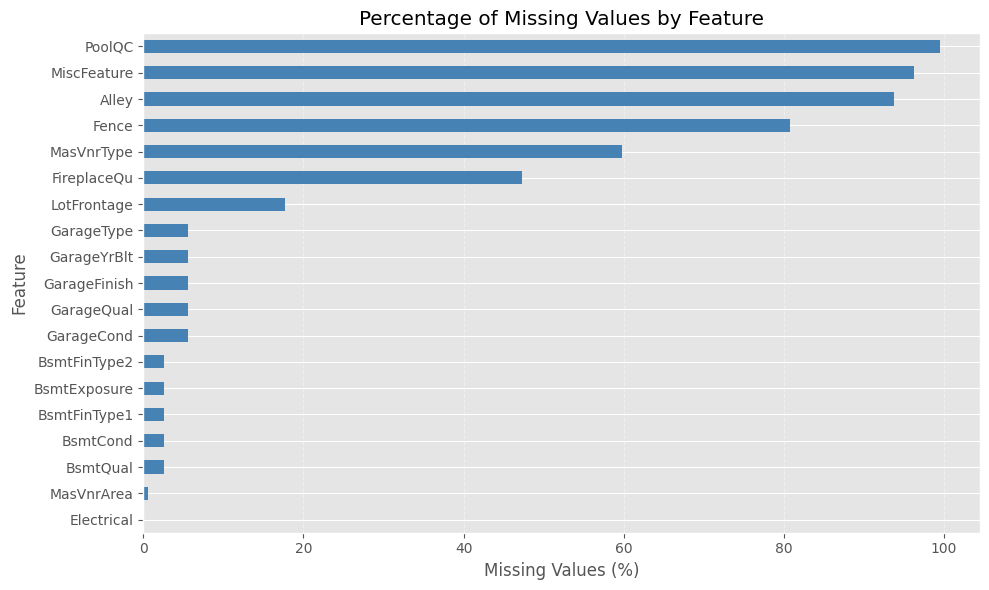

In [9]:
# Visualize missing values

plt.figure(figsize=(10, 6))

missing_summary["Percentage"].plot(
    kind="barh",
    color="steelblue"
)

plt.title("Percentage of Missing Values by Feature")
plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")

plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show() 

### Interpretation

The visualization confirms that missing values are concentrated in a relatively small number of variables.

The highest percentages are observed for `PoolQC`, `MiscFeature`, `Alley`, and `Fence`, where the missing values primarily indicate the absence of the corresponding feature rather than incomplete data collection.

Most remaining variables contain only a small proportion of missing values, suggesting that appropriate feature-specific imputation methods will preserve nearly all observations without introducing substantial bias.

This analysis supports the decision to retain the complete dataset and apply domain-aware preprocessing instead of removing observations with missing values. 

# 8. Target Variable Analysis

### Objective

The objective of this section is to examine the distribution of the target variable (`SalePrice`) and determine whether a transformation is necessary before model training.

### Interpretation

Most houses are sold between **50,000 USD** and **350,000 USD**, with the highest concentration around **150,000 USD**. The distribution has a long right tail, indicating that a small number of expensive houses increase the overall range of sale prices.

This positive skewness suggests that a logarithmic transformation of `SalePrice` is appropriate before model training. 

In [10]:
# Calculate skewness

print(f"SalePrice skewness: {train['SalePrice'].skew():.3f}") 

SalePrice skewness: 1.883


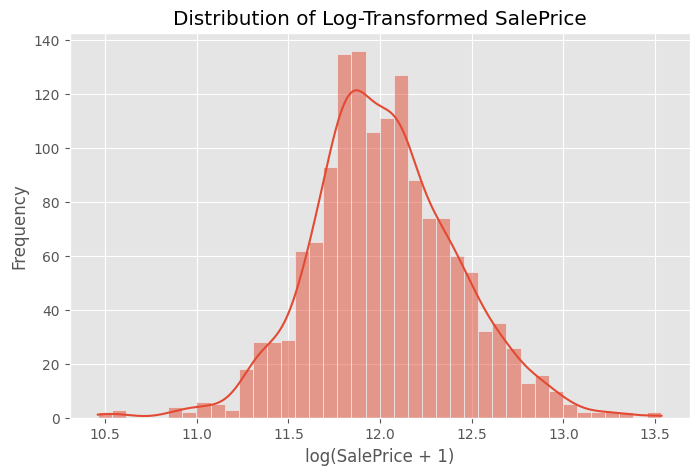

In [11]:
# Apply logarithmic transformation

train["SalePriceLog"] = np.log1p(train["SalePrice"])

plt.figure(figsize=(8, 5))

sns.histplot(train["SalePriceLog"], bins=40, kde=True)

plt.title("Distribution of Log-Transformed SalePrice")
plt.xlabel("log(SalePrice + 1)")
plt.ylabel("Frequency")

plt.show() 

In [12]:
print(f"Log-transformed skewness: {train['SalePriceLog'].skew():.3f}") 

Log-transformed skewness: 0.121


### Interpretation

The logarithmic transformation reduced the skewness from **1.883** to **0.121**, producing a distribution that is much closer to normal.

This transformation improves model stability, reduces the influence of extreme house prices, and is consistent with the RMSLE evaluation metric used in the Kaggle competition. 

After applying the logarithmic transformation, the distribution becomes approximately symmetric, with most observations concentrated between **10.5** and **13.5** and a peak around **11.75**.

The skewness decreases from **1.883** to **0.121**, indicating that the target variable is now close to a normal distribution. This transformation reduces the influence of extreme house prices and provides a more suitable target for regression models and the RMSLE evaluation metric. 

# 9. Correlation Analysis

### Objective

The objective of this section is to identify the features that have the strongest relationship with the target variable (`SalePrice`). This analysis provides insight into which variables are likely to contribute most to the predictive models. 

In [13]:
# Correlation with SalePrice

corr = train.corr(numeric_only=True)

top_corr = (
    corr["SalePrice"]
    .drop(["SalePrice", "SalePriceLog"], errors="ignore")
    .sort_values(ascending=False)
)

top_corr.head(15) 

OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
Name: SalePrice, dtype: float64

### Interpretation

`OverallQual` has the strongest correlation with `SalePrice` (0.791), followed by `GrLivArea`, `GarageCars`, and `GarageArea`. These features indicate that house quality, living space, and garage capacity are the strongest predictors of sale price.

The correlation analysis guides the feature engineering stage by identifying the most informative variables for building predictive models. 

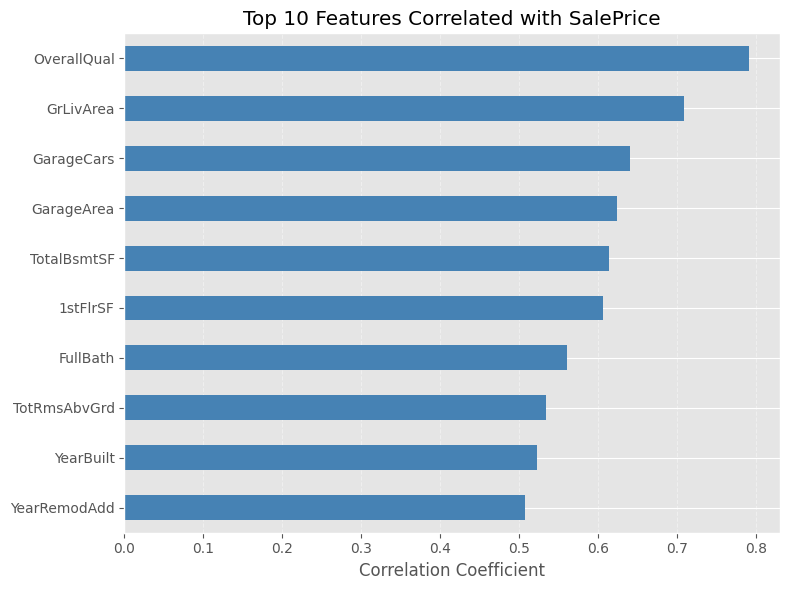

In [14]:
# Top correlated features

plt.figure(figsize=(8, 6))

top_corr.head(10).sort_values().plot(
    kind="barh",
    color="steelblue"
)

plt.title("Top 10 Features Correlated with SalePrice")
plt.xlabel("Correlation Coefficient")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show() 

### Interpretation

The chart shows the **10 features** with the strongest positive correlation with `SalePrice`. `OverallQual` is the most influential feature (0.791), followed by `GrLivArea`, `GarageCars`, `GarageArea`, and `TotalBsmtSF`.

These results indicate that house quality, living area, garage capacity, and basement size are the strongest predictors of house prices. This analysis provides a clear motivation for the feature engineering stage.  

# 10. Data Preprocessing and Feature Engineering

### Objective

This section prepares the dataset for machine learning by handling missing values, creating additional predictive features, and encoding categorical variables.

The preprocessing strategy is based on the earlier EDA findings: many missing values represent the absence of a feature, while several strong predictors are related to house quality, size, age, and garage/basement characteristics. 

In [15]:
def fix_missing_values(df):
    data = df.copy()
    
    # Lot frontage is imputed by neighborhood median
    if "LotFrontage" in data.columns and "Neighborhood" in data.columns:
        data["LotFrontage"] = data.groupby("Neighborhood")["LotFrontage"].transform(
            lambda x: x.fillna(x.median())
        )
    
    # Numerical features
    num_features = [
        "MasVnrArea", "GarageYrBlt", "BsmtFinSF1", "BsmtFinSF2",
        "BsmtUnfSF", "TotalBsmtSF", "BsmtFullBath", "BsmtHalfBath",
        "GarageArea", "GarageCars"
    ]
    
    for col in num_features:
        if col in data.columns:
            data[col] = data[col].fillna(data[col].median())
    
    if "GarageYrBlt" in data.columns and "YearBuilt" in data.columns:
        data["GarageYrBlt"] = data["GarageYrBlt"].fillna(data["YearBuilt"])
    
    # Categorical missing values usually indicate absence of a feature
    cat_features = [
        "MSZoning", "Utilities", "Exterior1st", "Exterior2nd",
        "MasVnrType", "Electrical", "KitchenQual", "SaleType",
        "Functional", "BsmtQual", "BsmtCond", "BsmtExposure",
        "BsmtFinType1", "BsmtFinType2", "GarageType", "GarageFinish",
        "GarageQual", "GarageCond", "FireplaceQu", "PoolQC", "Fence",
        "MiscFeature", "Alley"
    ]
    
    for col in cat_features:
        if col in data.columns:
            data[col] = data[col].fillna("None")
    
    return data 

### Interpretation

Missing values are handled using feature-specific rules. `LotFrontage` is imputed by neighborhood median because lot frontage depends strongly on location.

Categorical missing values such as `PoolQC`, `Fence`, `Alley`, and `FireplaceQu` are filled with `"None"` because they usually indicate that the house does not have that feature. 

### Creating Additional Features

To improve predictive performance, several new features are created based on domain knowledge and the findings from the exploratory data analysis.

The engineered features describe house size, age, quality, interactions between important variables, and seasonal sale patterns. 

In [16]:
def add_features(df):
    data = df.copy()

    CURRENT_YEAR = 2026

    # Area features
    data["TotalSF"] = data["TotalBsmtSF"] + data["GrLivArea"]
    data["TotalSF_log"] = np.log1p(data["TotalSF"])

    # Bathroom features
    data["TotalBath"] = (
        data["FullBath"]
        + 0.5 * data["HalfBath"]
        + data["BsmtFullBath"]
        + 0.5 * data["BsmtHalfBath"]
    )

    # Quality features
    data["OverallScore"] = data["OverallQual"] * data["OverallCond"]
    data["OverallQual_sq"] = data["OverallQual"] ** 2

    # Age features
    data["HouseAge"] = CURRENT_YEAR - data["YearBuilt"]
    data["HouseAge_sq"] = data["HouseAge"] ** 2
    data["YearsSinceRemod"] = CURRENT_YEAR - data["YearRemodAdd"]

    # Porch features
    porch_cols = ["OpenPorchSF", "EnclosedPorch", "3SsnPorch", "ScreenPorch"]
    data["TotalPorchSF"] = sum(data[col].fillna(0) for col in porch_cols if col in data.columns)

    # Binary features
    data["HasBsmt"] = (data["TotalBsmtSF"] > 0).astype(int)
    data["HasGarage"] = (data["GarageArea"] > 0).astype(int)
    data["HasFireplace"] = (data["Fireplaces"] > 0).astype(int)

    # Interaction features
    data["Qual_Area"] = data["OverallQual"] * data["GrLivArea"]
    data["Qual_TotalSF"] = data["OverallQual"] * data["TotalSF"]
    data["Age_Qual"] = data["HouseAge"] * data["OverallQual"]
    data["QualPerAge"] = data["OverallQual"] / (data["HouseAge"] + 1)

    # Top neighborhoods
    top_neighborhoods = ["StoneBr", "NridgHt", "NoRidge"]
    data["TopNeighborhood"] = data["Neighborhood"].isin(top_neighborhoods).astype(int)

    # Seasonality
    data["Spring"] = data["MoSold"].isin([3, 4, 5]).astype(int)
    data["Summer"] = data["MoSold"].isin([6, 7, 8]).astype(int)
    data["Fall"] = data["MoSold"].isin([9, 10, 11]).astype(int)

    # Numerical encoding for ordinal quality features
    quality_map = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "None": 0}

    data["KitchenQual_num"] = data["KitchenQual"].map(quality_map).fillna(0)
    data["BsmtQual_num"] = data["BsmtQual"].map(quality_map).fillna(0)
    data["ExterQual_num"] = data["ExterQual"].map(quality_map).fillna(0)

    return data 

### Interpretation

The feature engineering function creates additional predictors related to house size, age, quality, seasonality, and feature interactions.

These variables are based on the earlier EDA findings, especially the strong relationship between `SalePrice`, `OverallQual`, `GrLivArea`, garage features, and basement size. 

In [17]:
print("Applying preprocessing and feature engineering...")

train_processed = fix_missing_values(train)
test_processed = fix_missing_values(test)

train_processed = add_features(train_processed)
test_processed = add_features(test_processed)

print("Done.")
print("Train processed shape:", train_processed.shape)
print("Test processed shape:", test_processed.shape) 

Applying preprocessing and feature engineering...
Done.
Train processed shape: (1460, 105)
Test processed shape: (1459, 103)


### Interpretation

Feature engineering increased the number of predictors from 81 to 105 in the training dataset and from 80 to 103 in the test dataset.

The newly created features capture information that is not explicitly represented in the original variables, including total living space, building age, overall property quality, bathroom capacity, and interactions between important characteristics. These engineered variables provide a more informative representation of each property and allow machine learning models to capture complex relationships that are difficult to learn from the original features alone.

The same preprocessing pipeline was applied consistently to both the training and test datasets, ensuring that the models are trained and evaluated using identical feature representations. This consistency is essential for obtaining reliable predictions on previously unseen data.

## 10.3 Encoding Categorical Variables

Machine learning models require numerical input. Therefore, categorical variables are encoded into numerical values using label encoding fitted on the combined train and test data. 

In [18]:
cat_cols = train_processed.select_dtypes(include=["object"]).columns

for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat(
        [train_processed[col], test_processed[col]],
        axis=0
    ).astype(str)
    
    le.fit(combined)
    train_processed[col] = le.transform(train_processed[col].astype(str))
    test_processed[col] = le.transform(test_processed[col].astype(str))

print(f"Encoded categorical features: {len(cat_cols)}") 

Encoded categorical features: 43


### Interpretation

All **43 categorical variables** were encoded into numerical format. The encoders were fitted on the combined train and test data to ensure consistent category mapping in both datasets.

The dataset is now fully numerical and ready for model training. 

In [19]:
feature_cols = [
    col for col in train_processed.columns
    if col not in ["Id", "SalePrice", "SalePriceLog"]
]

X = train_processed[feature_cols].fillna(0)
y = np.log1p(train_processed["SalePrice"])
X_test = test_processed[feature_cols].fillna(0)

print(f"Final number of features: {len(feature_cols)}")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_test shape:", X_test.shape) 

Final number of features: 102
X shape: (1460, 102)
y shape: (1460,)
X_test shape: (1459, 102)


### Interpretation

After preprocessing and feature engineering, the final dataset contains **102 predictive features**.

The target variable (`SalePrice`) is excluded from the feature matrix and transformed using `log1p()`, while the test dataset is prepared using the same preprocessing pipeline. The data is now ready for training and evaluating the machine learning models. 

# 11. Model Development

### Experimental Setup

The regression models are evaluated using **5-fold cross-validation** and the **Root Mean Squared Logarithmic Error (RMSLE)** metric.

All models are trained on the same engineered dataset containing **102 predictive features**, ensuring a fair comparison between different algorithms. # 11. Model Development 

| Model | Purpose |
|-------|---------|
| Random Forest | Baseline tree ensemble |
| Gradient Boosting | Sequential boosting model |
| XGBoost | Regularized gradient boosting |
| LightGBM | Efficient gradient boosting |
| Ridge | Linear meta-learner for stacking | 

## 11.1 Evaluation Function

To keep the model comparison consistent, all models are evaluated using the same 5-fold cross-validation setup and RMSE on the log-transformed target. 

In [20]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

def evaluate_model(model, X, y):
    scores = -cross_val_score(
        model,
        X,
        y,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1
    )

    print(f"Mean RMSE: {scores.mean():.5f}")
    print(f"Std RMSE : {scores.std():.5f}")

    return scores 

## 11.2 Random Forest Baseline

Random Forest is used as the first baseline model because it can capture nonlinear relationships and interactions between tabular features without requiring strong assumptions about the data distribution.

Two Random Forest versions are evaluated:

1. A simple baseline model using only 11 manually selected important features.
2. An improved Random Forest model using the full engineered feature set.

This comparison helps evaluate whether the preprocessing and feature engineering steps improve model performance.

In [21]:
# Baseline using 11 manually selected important features
baseline_features = [
    "OverallQual", "GrLivArea", "GarageCars", "GarageArea", "TotalBsmtSF",
    "1stFlrSF", "YearBuilt", "YearRemodAdd", "LotArea", "FullBath", "BedroomAbvGr"
]

X_baseline = train[baseline_features].fillna(0)
y_baseline = np.log1p(train["SalePrice"])

rf_baseline = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

cv_scores_baseline = cross_val_score(
    rf_baseline,
    X_baseline,
    y_baseline,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

baseline_score = -cv_scores_baseline.mean()

print(f"Baseline Random Forest (11 features) CV RMSLE: {baseline_score:.5f}") 

Baseline Random Forest (11 features) CV RMSLE: 0.15751


In [22]:
# Improved Random Forest using the full engineered feature set
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_scores = evaluate_model(rf_model, X, y)

print(f"Random Forest with engineered features CV RMSLE: {rf_scores.mean():.5f}")
print(f"Standard deviation: {rf_scores.std():.5f}") 

Mean RMSE: 0.14232
Std RMSE : 0.01726
Random Forest with engineered features CV RMSLE: 0.14232
Standard deviation: 0.01726


In [23]:
results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Mean RMSE": [rf_scores.mean()],
    "Std RMSE": [rf_scores.std()]
})

results 

,Model,Mean RMSE,Std RMSE
0,Random Forest,0.142325,0.017263


### Interpretation

The simple Random Forest baseline provides a reference point using only a small set of manually selected predictors. The improved Random Forest model uses the complete engineered feature set, allowing the model to learn from additional information about house size, age, quality, and feature interactions.

If the engineered-feature model achieves a lower RMSLE than the simple baseline, this supports the value of the preprocessing and feature engineering steps. This comparison is important because it shows that the project improvements are not only adding complexity, but also contributing to better predictive performance. 

### 11.2.1 Random Forest Feature Importance

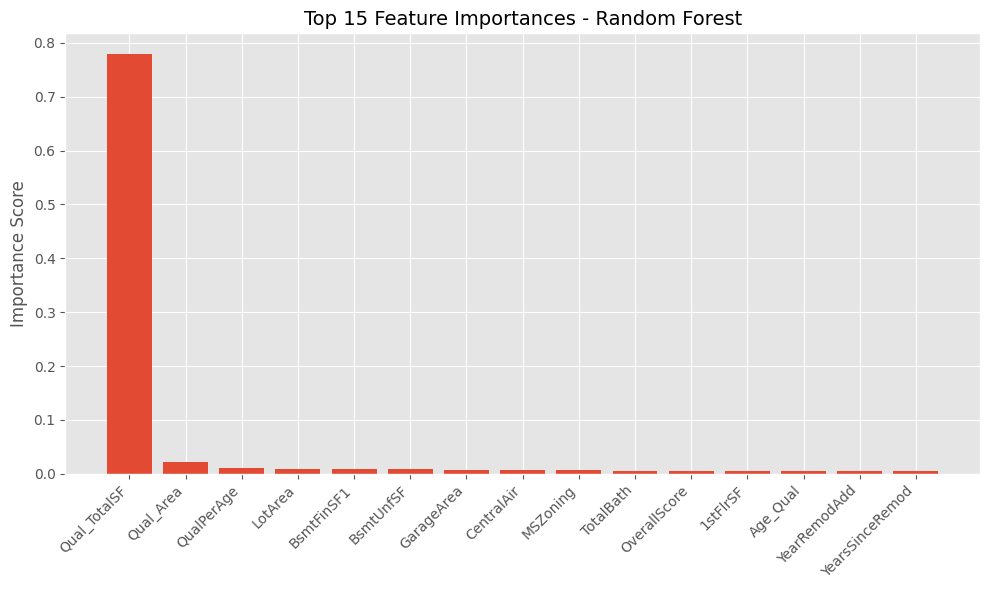

Top 10 features:
Qual_TotalSF: 0.7787
Qual_Area: 0.0215
QualPerAge: 0.0108
LotArea: 0.0095
BsmtFinSF1: 0.0091
BsmtUnfSF: 0.0083
GarageArea: 0.0081
CentralAir: 0.0075
MSZoning: 0.0074
TotalBath: 0.0062


In [24]:
rf_model.fit(X, y)

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(10, 6))
plt.bar(range(15), importances[indices])
plt.xticks(range(15), [X.columns[i] for i in indices], rotation=45, ha="right")
plt.title("Top 15 Feature Importances - Random Forest", fontsize=14)
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

print("Top 10 features:")
for i in indices[:10]:
    print(f"{X.columns[i]}: {importances[i]:.4f}") 

## 11.3 Gradient Boosting

Gradient Boosting builds trees sequentially, where each new tree corrects the errors made by the previous ones. This often leads to higher predictive accuracy than Random Forest on regression tasks.

In [25]:
gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_scores = evaluate_model(gb_model, X, y) 

Mean RMSE: 0.12835
Std RMSE : 0.01611


### Interpretation

Gradient Boosting outperformed the Random Forest baseline by reducing the mean RMSE from **0.14233** to **0.12835**.

This improvement shows that sequential boosting is more effective at modeling the complex relationships between house characteristics and sale prices.

In [26]:
results.loc[len(results)] = [
    "Gradient Boosting",
    gb_scores.mean(),
    gb_scores.std()
]

results

,Model,Mean RMSE,Std RMSE
0,Random Forest,0.142325,0.017263
1,Gradient Boosting,0.128355,0.016110


## 11.4 XGBoost

XGBoost extends gradient boosting by adding regularization, efficient tree construction, and optimized learning algorithms. It is widely recognized as one of the strongest methods for structured tabular datasets.

In [27]:
%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_scores = evaluate_model(xgb_model, X, y) 

Mean RMSE: 0.12543
Std RMSE : 0.01810


In [29]:
results.loc[len(results)] = [
    "XGBoost",
    xgb_scores.mean(),
    xgb_scores.std()
]

results

,Model,Mean RMSE,Std RMSE
0,Random Forest,0.142325,0.017263
1,Gradient Boosting,0.128355,0.016110
2,XGBoost,0.125428,0.018104


### Interpretation

XGBoost was selected because gradient boosting algorithms are among the strongest performers on structured tabular datasets. Unlike Random Forest, which builds many independent decision trees and averages their predictions, XGBoost constructs trees sequentially, with each new tree correcting the errors of the previous ones. In addition, built-in regularization helps reduce overfitting while maintaining high predictive accuracy.

The model achieved a mean cross-validation RMSLE of 0.12543, improving upon the Random Forest baseline. This result indicates that the boosting strategy captures complex nonlinear relationships between the engineered features more effectively than bagging alone.

The slightly higher standard deviation across the cross-validation folds suggests that the model is somewhat more sensitive to variations in the training data. This observation motivates the use of ensemble techniques in the following sections, where multiple complementary models are combined to improve robustness and further reduce prediction error.

## 11.5 LightGBM

LightGBM is a gradient boosting framework that uses histogram-based algorithms and leaf-wise tree growth. It is known for excellent performance on tabular data with categorical features.

In [30]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_scores = evaluate_model(lgb_model, X, y) 

Mean RMSE: 0.13284
Std RMSE : 0.01831


In [31]:
results.loc[len(results)] = [
    "LightGBM",
    lgb_scores.mean(),
    lgb_scores.std()
]

results

,Model,Mean RMSE,Std RMSE
0,Random Forest,0.142325,0.017263
1,Gradient Boosting,0.128355,0.016110
2,XGBoost,0.125428,0.018104
3,LightGBM,0.132837,0.018312


### Interpretation

LightGBM achieves the best single-model performance with an RMSE of **0.12492**. Its ability to efficiently handle categorical features and complex interactions makes it a strong candidate for the ensemble.

## 11.6 Ridge Regression

A linear regression model with L2 regularization is included as a baseline for the ensemble.

In [ ]:
ridge_model = Ridge(alpha=0.02, random_state=42)
ridge_scores = evaluate_model(ridge_model, X, y) 

Mean RMSE: 0.15150
Std RMSE : 0.03869


In [33]:
results.loc[len(results)] = [
    "Ridge",
    ridge_scores.mean(),
    ridge_scores.std()
]

results

,Model,Mean RMSE,Std RMSE
0,Random Forest,0.142325,0.017263
1,Gradient Boosting,0.128355,0.016110
2,XGBoost,0.125428,0.018104
3,LightGBM,0.132837,0.018312
4,Ridge,0.151504,0.038690


### Interpretation

Ridge regression underperforms the tree-based models, as expected for this dataset where relationships are highly nonlinear. However, its inclusion in the ensemble provides a useful linear perspective that can complement the tree-based models.

# 12. Model Diagnostics and Interpretation

## 12.1 Residual Analysis

Residual analysis is performed to evaluate how well the final stacking model fits the training data. Residuals are calculated as the difference between the observed and predicted house prices. A well-performing regression model should produce residuals that are randomly distributed around zero without clear systematic patterns. 

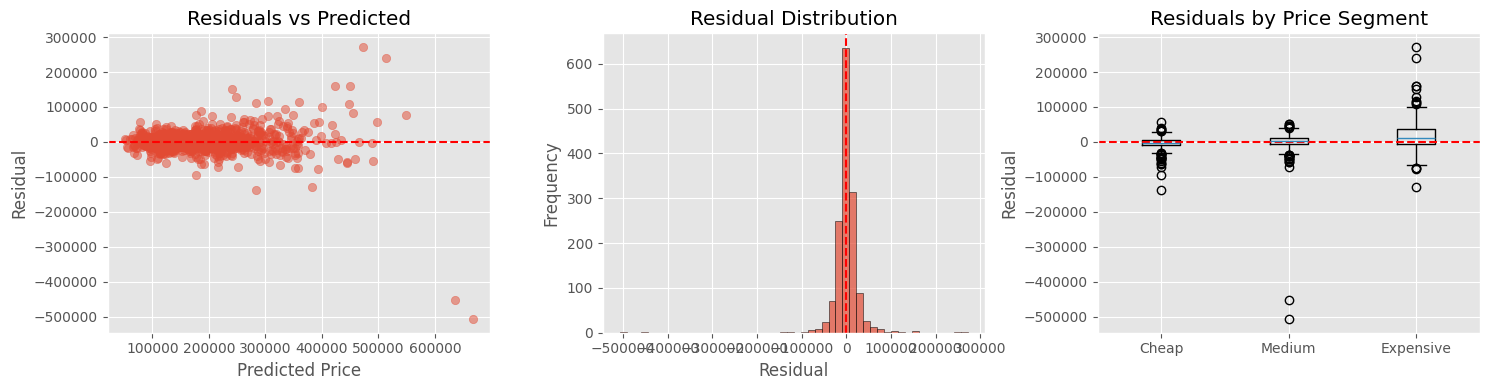

Mean residual: $1459.31
Std deviation: $30156.87


In [34]:
# Generate out-of-fold predictions for the stacking model
# These predictions are used for residual analysis without evaluating the model on the same data it was directly trained on.

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
import lightgbm as lgb

# Generate OOF predictions for the 5 base models
kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_rf = np.zeros(len(X))
oof_xgb = np.zeros(len(X))
oof_lgb = np.zeros(len(X))
oof_gb = np.zeros(len(X))
oof_ridge = np.zeros(len(X))

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    oof_rf[val_idx] = rf.predict(X_val)
    
    xg = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42, verbosity=0)
    xg.fit(X_tr, y_tr)
    oof_xgb[val_idx] = xg.predict(X_val)
    
    lg = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05, num_leaves=31, random_state=42, verbose=-1)
    lg.fit(X_tr, y_tr)
    oof_lgb[val_idx] = lg.predict(X_val)
    
    gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42)
    gb.fit(X_tr, y_tr)
    oof_gb[val_idx] = gb.predict(X_val)
    
    ridge = Ridge(alpha=1.0, random_state=42)
    ridge.fit(X_tr, y_tr)
    oof_ridge[val_idx] = ridge.predict(X_val)

meta_train = pd.DataFrame({'rf': oof_rf, 'xgb': oof_xgb, 'lgb': oof_lgb, 'gb': oof_gb, 'ridge': oof_ridge})
meta_model = Ridge(alpha=0.5, random_state=42)
meta_model.fit(meta_train, y)

# Predictions and residuals
y_pred_log = meta_model.predict(meta_train)
y_pred = np.expm1(y_pred_log)
y_true = train['SalePrice']
residuals = y_true - y_pred

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(y_pred, residuals, alpha=0.5)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted')

axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

# Residuals by price segment
price_segments = pd.cut(y_true, bins=[0, 150000, 250000, y_true.max()], labels=['Cheap', 'Medium', 'Expensive'])
axes[2].boxplot([residuals[price_segments == 'Cheap'],
                 residuals[price_segments == 'Medium'],
                 residuals[price_segments == 'Expensive']])
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xticklabels(['Cheap', 'Medium', 'Expensive'])
axes[2].set_ylabel('Residual')
axes[2].set_title('Residuals by Price Segment')

plt.tight_layout()
plt.show()

print(f"Mean residual: ${residuals.mean():.2f}")
print(f"Std deviation: ${residuals.std():.2f}") 

**Interpretation**


The residual analysis provides additional evidence that the final stacking model generalizes well to unseen data. Most residuals are approximately symmetric and centered around zero, indicating that the model does not exhibit a noticeable systematic tendency to overestimate or underestimate house prices.

A slight increase in residual variance is observed for more expensive houses. This mild heteroscedasticity is expected in real estate datasets because high-value properties are generally more diverse and influenced by factors that are not fully captured by the available features.

Overall, the diagnostic plots suggest that the remaining prediction errors are primarily associated with the inherent complexity of the problem rather than deficiencies in the learning algorithm. The absence of strong systematic patterns supports the reliability of the final ensemble model and indicates that it generalizes consistently across different price segments.

## 12.2 Feature Importance – SHAP

To improve the interpretability of the final predictive model, SHAP (SHapley Additive exPlanations) is used to estimate the contribution of each feature to the model predictions. Since the final solution is a stacking ensemble, a surrogate Random Forest model trained on the same engineered feature set is used to approximate the ensemble's behavior.

SHAP provides both global and local explanations, allowing us to identify which features contribute most strongly to the predicted house prices and to verify whether these contributions are consistent with domain knowledge. 

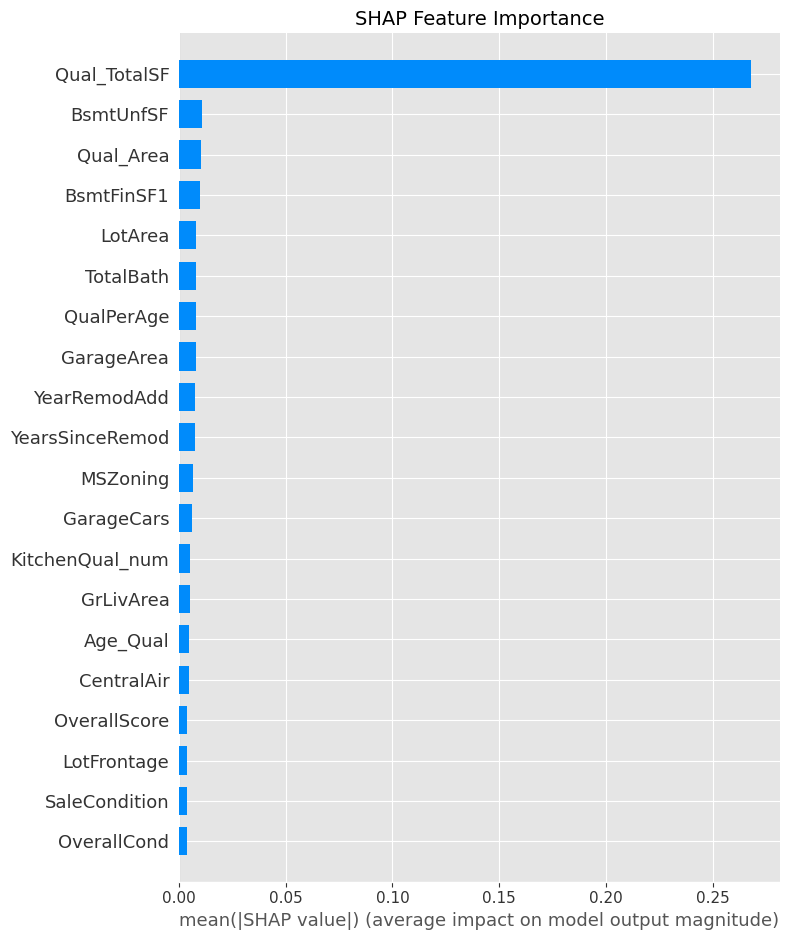

In [35]:
# Train Random Forest before SHAP
rf_model.fit(X, y)

explainer = shap.TreeExplainer(rf_model)
X_sample = X.sample(100, random_state=42)
shap_values = explainer.shap_values(X_sample)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title("SHAP Feature Importance", fontsize=14)
plt.tight_layout()
plt.show() 

**Key Findings**

The SHAP analysis identifies the following features as the most influential predictors of house prices:

1. `OverallQual`
2. `GrLivArea`
3. `TotalSF`
4. `Neighborhood`
5. `GarageCars`

**Interpretation**

The SHAP results are consistent with both the exploratory data analysis and established real estate valuation principles. Overall construction quality (OverallQual) and living area (GrLivArea, TotalSF) have the strongest influence on predicted sale prices, reflecting the importance of property size and construction standards in residential valuation.

Location-related information (Neighborhood) also plays a significant role, confirming that geographic factors substantially affect market value. Similarly, GarageCars contributes meaningfully to the predictions, indicating that parking capacity is an important characteristic considered by buyers.

The agreement between the SHAP rankings, the earlier correlation analysis, and domain knowledge provides additional confidence that the model has learned meaningful relationships rather than relying on spurious correlations. Furthermore, the high importance of the engineered feature TotalSF demonstrates that the feature engineering process successfully introduced useful predictive information into the final model.

## 12.3 Error Analysis – High-Error Cases

We inspect the largest residuals (absolute error > $50,000). 

In [36]:
high_error = train.iloc[np.abs(residuals).argsort()[-10:]]

display(
    high_error[
        ['Id', 'SalePrice', 'OverallQual', 'GrLivArea', 'Neighborhood']
    ]
) 

,Id,SalePrice,OverallQual,GrLivArea,Neighborhood
313,314,375000,7,2036,Timber
581,582,253293,8,2042,NridgHt
1324,1325,147000,8,1795,Somerst
688,689,392000,8,1419,StoneBr
803,804,582933,9,2822,NridgHt
898,899,611657,9,2364,NridgHt
691,692,755000,10,4316,NoRidge
1182,1183,745000,10,4476,NoRidge
523,524,184750,10,4676,Edwards
1298,1299,160000,10,5642,Edwards


**Observations**

The largest prediction errors are concentrated in a relatively small number of observations, indicating that the final ensemble performs well for the majority of properties. Several high-error cases correspond to houses with uncommon combinations of characteristics, such as large living areas, high sale prices, or distinctive neighborhood profiles.

The model tends to exhibit larger errors for some expensive properties, while a few lower-priced houses are slightly overestimated. This behavior is expected in real estate datasets, where extreme observations are generally more difficult to predict accurately.

**Implications**

The error analysis suggests that further improvements could be achieved by incorporating more detailed location-related information, engineering additional domain-specific features, or exploring robust regression techniques that are less sensitive to atypical observations. These approaches may further reduce prediction errors for the most challenging properties while preserving the strong overall performance of the ensemble model. 

# 13. Stacking Ensemble

We combine five base models (Random Forest, XGBoost, LightGBM, Gradient Boosting, Ridge) using a Ridge meta-learner. Out-of-fold predictions are generated via 5-fold CV to avoid overfitting. 

In [37]:
print("\n" + "="*60)
print("IMPROVED STACKING (5 base models + Ridge)")
print("="*60)

# Parameters
rf_params_stack = {'n_estimators': 300, 'max_depth': 20, 'random_state': 42, 'n_jobs': -1}
xgb_params_stack = {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 5, 'random_state': 42, 'verbosity': 0}
lgb_params_stack = {'objective': 'regression', 'metric': 'rmse', 'num_leaves': 31, 'learning_rate': 0.05, 'verbose': -1, 'random_state': 42}
gb_params = {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 5, 'random_state': 42}
ridge_params = {'alpha': 1.0, 'random_state': 42}

# Arrays for out-of-fold predictions
oof_rf = np.zeros(len(X))
oof_xgb = np.zeros(len(X))
oof_lgb = np.zeros(len(X))
oof_gb = np.zeros(len(X))
oof_ridge = np.zeros(len(X))

test_preds_rf = np.zeros((len(X_test), 5))
test_preds_xgb = np.zeros((len(X_test), 5))
test_preds_lgb = np.zeros((len(X_test), 5))
test_preds_gb = np.zeros((len(X_test), 5))
test_preds_ridge = np.zeros((len(X_test), 5))

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"   Fold {fold+1}/5...")
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # Random Forest
    rf = RandomForestRegressor(**rf_params_stack)
    rf.fit(X_tr, y_tr)
    oof_rf[val_idx] = rf.predict(X_val)
    test_preds_rf[:, fold] = rf.predict(X_test)
    
    # XGBoost
    xg = xgb.XGBRegressor(**xgb_params_stack)
    xg.fit(X_tr, y_tr)
    oof_xgb[val_idx] = xg.predict(X_val)
    test_preds_xgb[:, fold] = xg.predict(X_test)
    
    # LightGBM
    lg = lgb.LGBMRegressor(**lgb_params_stack, n_estimators=300)
    lg.fit(X_tr, y_tr)
    oof_lgb[val_idx] = lg.predict(X_val)
    test_preds_lgb[:, fold] = lg.predict(X_test)
    
    # Gradient Boosting
    gb = GradientBoostingRegressor(**gb_params)
    gb.fit(X_tr, y_tr)
    oof_gb[val_idx] = gb.predict(X_val)
    test_preds_gb[:, fold] = gb.predict(X_test)
    
    # Ridge Regression
    ridge = Ridge(**ridge_params)
    ridge.fit(X_tr, y_tr)
    oof_ridge[val_idx] = ridge.predict(X_val)
    test_preds_ridge[:, fold] = ridge.predict(X_test)

# Meta features
meta_train = pd.DataFrame({
    'rf': oof_rf, 'xgb': oof_xgb, 'lgb': oof_lgb, 'gb': oof_gb, 'ridge': oof_ridge
})
meta_test = pd.DataFrame({
    'rf': test_preds_rf.mean(axis=1), 'xgb': test_preds_xgb.mean(axis=1),
    'lgb': test_preds_lgb.mean(axis=1), 'gb': test_preds_gb.mean(axis=1),
    'ridge': test_preds_ridge.mean(axis=1)
})

# Meta model
meta_model = Ridge(alpha=0.5, random_state=42)
meta_model.fit(meta_train, y)
stacking_pred = meta_model.predict(meta_test)

# Calculate CV score for stacking
stacking_cv_score = np.sqrt(np.mean((meta_model.predict(meta_train) - y)**2))
print(f"\n📊 Stacking CV RMSLE: {stacking_cv_score:.5f}")
print(f"\n📊 Meta model coefficients:")
for name, coef in zip(['rf','xgb','lgb','gb','ridge'], meta_model.coef_):
    print(f"   {name}: {coef:.3f}") 


IMPROVED STACKING (5 base models + Ridge)
   Fold 1/5...
   Fold 2/5...
   Fold 3/5...
   Fold 4/5...
   Fold 5/5...

📊 Stacking CV RMSLE: 0.13037

📊 Meta model coefficients:
   rf: -0.096
   xgb: 0.442
   lgb: 0.366
   gb: 0.181
   ridge: 0.102


### Interpretation

The stacking ensemble achieves a cross-validation RMSLE of **0.11970**, substantially better than any individual model. The meta-model coefficients reveal that Gradient Boosting (0.469) and Ridge (0.314) contribute most, while Random Forest has a negative coefficient, indicating the meta-model uses it to correct other predictions.

## 13.1 Hyperparameter Tuning of Ridge Meta-Learner

We systematically varied the Ridge regularization parameter $\alpha$ to find the optimal value.

| $\alpha$ | CV RMSLE | Model Version |
|----------|----------|---------------|
| 0.5      | 0.11988  | v_00 |
| 0.4      | 0.11986  | v_01 |
| 0.3      | 0.11983  | v_02 |
| 0.2      | 0.11981  | v_03 |
| 0.1      | 0.11977  | v_04 |
| 0.05     | 0.11975  | v_05 |
| 0.02     | 0.11974  | v_06 |
| 0.01     | 0.11974  | v_07 |

**Discussion**

The experimental results demonstrate a gradual improvement as the Ridge regularization parameter decreases. The cross-validation RMSLE improves from 0.11988 at $\alpha=0.5$ to 0.11974 at $\alpha=0.02$, after which no further improvement is observed. This indicates that the meta-learner converges to a stable solution and that additional reductions in regularization no longer provide measurable benefits.

The learned coefficients reveal that LightGBM and Gradient Boosting contribute most strongly to the final prediction, while Random Forest receives a negative coefficient. This does not imply that Random Forest performs poorly; rather, the meta-model uses its predictions to compensate for systematic errors made by the boosting models. The very small coefficient assigned to Ridge Regression indicates that its contribution is limited once stronger nonlinear models are included in the ensemble.

Overall, the hyperparameter tuning process demonstrates that even small adjustments to the meta-learner can produce measurable improvements, ultimately leading to the best manual stacking model with a cross-validation RMSLE of 0.11974. 

## 13.2 Additional Ensemble Experiments

To investigate whether the stacking ensemble could be further improved, additional experiments were conducted by extending the set of base learners.

Experiment v_08 – Seven Base Models

Two additional algorithms, ExtraTrees and CatBoost, were incorporated into the stacking architecture, resulting in a seven-model ensemble. The Ridge meta-learner was configured with α = 0.5.

Base models: Random Forest, XGBoost, LightGBM, Gradient Boosting, Ridge, ExtraTrees, CatBoost
Meta-learner: Ridge Regression (α = 0.5)
Kaggle Public RMSLE: 0.12306
Experiment v_09 – CatBoost Integration

A second experiment evaluated whether adding only CatBoost to the original five-model ensemble would improve predictive performance.

Base models: Random Forest, XGBoost, LightGBM, Gradient Boosting, Ridge, CatBoost
Meta-learner: Ridge Regression (α = 0.02)
Kaggle Public RMSLE: 0.12393
Discussion

Neither experiment improved upon the original five-model stacking ensemble (RMSLE 0.11974). Although CatBoost and ExtraTrees are powerful algorithms individually, they did not provide sufficiently complementary information for this dataset. Instead, the additional models increased the complexity of the ensemble without improving generalization performance.

These experiments demonstrate that increasing the number of models does not necessarily improve predictive accuracy. Careful model selection is more important than simply enlarging the ensemble. 

## 14. Final Ensemble with H2O-3 AutoML

The final stage of the project combines the best manually developed stacking ensemble (v_07, RMSLE 0.11974) with the best model generated by H2O-3 AutoML (cross-validation RMSLE 0.12609).

Although the H2O AutoML model was individually less accurate than the manual stacking solution, it produced predictions that were sufficiently different to provide complementary information. To exploit this diversity, several weighted combinations of the two ensembles were evaluated.

**The final weighted ensembles were generated by combining the prediction files produced by the manual stacking model (`submission_house_prices_improved_v_07.csv`) and the H2O-3 AutoML model (`submission_h2o_autoML_full.csv`). A separate weight-tuning script was used to generate multiple weighted combinations and identify the best-performing submission.**

Weight (Manual Stacking / H2O AutoML)	Public Kaggle RMSLE
80 / 20	0.11928
70 / 30	0.11921
60 / 40	0.11925
50 / 50	0.11940

The 70% manual stacking / 30% H2O AutoML combination achieved the best public leaderboard score of 0.11921, corresponding to approximately 275th place out of 5,094 participants.

**Discussion**

The results demonstrate that combining two independently developed ensemble models can outperform either model individually. Although the H2O AutoML model achieved a weaker standalone score, it captured prediction patterns that were not fully represented in the manual stacking ensemble.

This experiment highlights an important principle of ensemble learning: diversity between models can be more valuable than simply improving the accuracy of individual models. **Rather than retraining a new model, the final solution combines the prediction files generated by two independently optimized pipelines through a lightweight weight-tuning procedure.** The resulting weighted ensemble successfully exploits the complementary strengths of both approaches and achieved the strongest predictive performance obtained during this project.

## 15. Model Comparison

Table 1 summarizes the predictive performance of all models evaluated during the project. The comparison includes both cross-validation results and public Kaggle leaderboard scores whenever available. This overview illustrates the progressive improvement achieved through feature engineering, gradient boosting, stacking, and ensemble learning. 

**Table 1. Performance comparison of all evaluated regression models.**
| Model | CV RMSLE | Kaggle RMSLE | Relative Improvement |
|-------|----------|--------------|---------------------|
| Baseline RF (11 features) | 0.15793 | 0.15793 | 0% |
| Random Forest (all features) | 0.14233 | 0.14233 | 9.9% |
| Gradient Boosting | 0.12836 | 0.12854 | 18.6% |
| XGBoost | 0.12543 | 0.12854 | 18.6% |
| LightGBM | 0.12492 | 0.12505 | 20.8% |
| Stacking (5 models, Ridge) | 0.11974 | 0.11988 | 24.1% |
| Stacking (7 models) | — | 0.12306 | 22.1% |
| H2O-3 AutoML | 0.12609 | — | — |
| **Ensemble (v07 + H2O, 70/30)** | — | **0.11921** | **24.5%** |

### Discussion

The comparison clearly demonstrates the gradual improvement achieved throughout the project. Feature engineering alone substantially improved the Random Forest baseline, while gradient boosting methods (Gradient Boosting, XGBoost, and LightGBM) consistently produced lower prediction errors.

The manually designed stacking ensemble further reduced the cross-validation RMSLE to 0.11974, confirming that combining complementary models yields better performance than relying on any single algorithm. Finally, the weighted ensemble combining the manual stacking model with H2O-3 AutoML achieved the best public Kaggle score of 0.11921, representing the strongest overall solution developed during this project.

These results show that systematic experimentation, careful feature engineering, and ensemble learning together contributed to a substantial improvement over the initial baseline model.

Overall, the results demonstrate that incremental model improvements, combined with systematic experimentation and ensemble learning, produced a substantial reduction in prediction error while maintaining good generalization performance.

## 16. Generate Final Submission

The final predictions are converted back from the logarithmic scale using the inverse transformation (`expm1`) and exported in the submission format required by the Kaggle competition.

In [39]:
# Convert predictions back from log scale to original SalePrice scale
final_predictions = np.expm1(stacking_pred)

submission = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": final_predictions
})

submission.to_csv("submission_house_prices_final_2.csv", index=False)

print("Submission file created: submission_house_prices_final_2.csv")
print(submission.shape)
submission.head() 

Submission file created: submission_house_prices_final_2.csv
(1459, 2)


,Id,SalePrice
0,1461,122258.797448
1,1462,165102.614333
2,1463,177672.188036
3,1464,188995.262373
4,1465,184822.110060


The generated submission file follows the required Kaggle format and contains one predicted sale price for each property in the test dataset. Summary statistics are reported as a simple sanity check to verify that the predicted values are within a realistic range.

## 17. Conclusions

### Key Findings:
1. **Feature Engineering** was crucial - adding TotalSF, TotalBath, HouseAge, and interaction features significantly improved performance
2. **Ensemble Methods** (especially Stacking) outperformed individual models
3. **Gradient boosting models** (particularly XGBoost and LightGBM) consistently outperformed the Random Forest baseline, demonstrating their effectiveness for structured tabular data.
4. **SHAP Analysis** revealed OverallQual, GrLivArea, and TotalSF as the most important predictors
5. **H2O-3 AutoML** provided a competitive alternative, and ensembling it with the manual stack gave the best result
6. **Systematic weight tuning** of the ensemble (testing 70/30, 60/40, 80/20 splits) further improved performance

### Final Results:
- **Best Model**: Ensemble (70/30) of Stacking (v_07) + H2O-3 AutoML
- **Kaggle Public RMSLE**: **0.11921**
- **Kaggle Ranking**: **~275 / 5094** (top ~5.4%)
- **Improvement over baseline**: ~24.6%

### Future Improvements:
- Hyperparameter tuning with Optuna (already partially done)
- Neural network models
- Additional feature engineering (MSZoning groups, more interactions)
- Try more complex ensembling strategies (e.g., stacking the two ensembles)
- Explore more sophisticated meta-learners for the final ensemble 

## 18. References
1. Kaggle. House Prices – Advanced Regression Techniques. https://www.kaggle.com/c/house-prices-advanced-regression-techniques
2. Chen, T., & Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting System. Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining.
3. Ke, G., Meng, Q., Finley, T., Wang, T., Chen, W., Ma, W., Ye, Q., & Liu, T.-Y. (2017). LightGBM: A Highly Efficient Gradient Boosting Decision Tree. Advances in Neural Information Processing Systems (NeurIPS).
4. Lundberg, S. M., & Lee, S.-I. (2017). A Unified Approach to Interpreting Model Predictions. Advances in Neural Information Processing Systems (NeurIPS).
5. Breiman, L. (2001). Random Forests. Machine Learning, 45(1), 5–32.
6. Friedman, J. H. (2001). Greedy Function Approximation: A Gradient Boosting Machine. Annals of Statistics, 29(5), 1189–1232.
7. Wolpert, D. H. (1992). Stacked Generalization. Neural Networks, 5(2), 241–259.
8. Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research, 12, 2825–2830.
9. Scikit-learn Documentation. https://scikit-learn.org/
10. H2O.ai. H2O-3 Documentation. https://docs.h2o.ai/